# Solar radiation data

Retrieved from ads.
doc: https://confluence.ecmwf.int/spaces/CKB/pages/266592908/CAMS+solar+radiation+time-series+data+documentation

In [2]:

try:
    from dotenv import load_dotenv, find_dotenv
    import os

    if not load_dotenv():
        load_dotenv(find_dotenv())


    HOST = os.getenv("HOST")
    if HOST is None:
        print("Variables not found. Check .env")

    else:
        PORT = os.getenv("PORT")
        USERNAME = os.getenv("USERNAME")
        PASSWORD = os.getenv("PASSWORD")
        DATABASE = os.getenv("DATABASE")

except:
    print("Cant load env")

In [3]:
import pandas as pd
import xarray as xr

In [4]:

file = "data/ESACCI-LST-L3S-LST-IRCDR_-0.01deg_1MONTHLY_DAY-20200701000000-fv3.00.area-subset.55.69.12.57.55.65.12.5.nc"

ds = xr.open_dataset(file, engine="netcdf4")

print(ds)

<xarray.Dataset> Size: 2kB
Dimensions:          (time: 1, lat: 4, lon: 7, length_scale: 1, channel: 2)
Coordinates:
  * time             (time) datetime64[ns] 8B 2020-07-01
  * lat              (lat) float32 16B 55.65 55.67 55.67 55.68
  * lon              (lon) float32 28B 12.51 12.51 12.52 12.53 12.54 12.56 12.56
  * channel          (channel) float32 8B 11.0 12.0
Dimensions without coordinates: length_scale
Data variables: (12/14)
    dtime            (time, lat, lon) float32 112B ...
    satze            (time, lat, lon) float32 112B ...
    sataz            (time, lat, lon) float32 112B ...
    solze            (time, lat, lon) float32 112B ...
    solaz            (time, lat, lon) float32 112B ...
    lst              (time, lat, lon) float32 112B ...
    ...               ...
    lst_unc_loc_atm  (time, lat, lon) float32 112B ...
    lst_unc_loc_sfc  (time, lat, lon) float32 112B ...
    lst_unc_sys      (length_scale) float32 4B ...
    lcc              (time, lat, lon) float32

In [5]:
df = ds.to_dataframe().reset_index()

print(df.head())
print(df.shape)

        time        lat        lon  length_scale    channel      dtime  \
0 2020-07-01  55.654995  12.505000             0  10.999001   899473.0   
1 2020-07-01  55.654995  12.505000             0  11.999001   899473.0   
2 2020-07-01  55.654995  12.514995             0  10.999001  1375116.0   
3 2020-07-01  55.654995  12.514995             0  11.999001  1375116.0   
4 2020-07-01  55.654995  12.524989             0  10.999001  1375116.0   

       satze      sataz      solze       solaz         lst  lst_uncertainty  \
0  13.009999  81.720001  37.110001  146.309998  298.690002            5.676   
1  13.009999  81.720001  37.110001  146.309998  298.690002            5.676   
2  10.679999  28.150000  37.509998  149.330002  297.660004            5.627   
3  10.679999  28.150000  37.509998  149.330002  297.660004            5.627   
4  10.670000  28.019999  37.509998  149.349991  298.139984            5.576   

   lst_unc_ran  lst_unc_loc_atm  lst_unc_loc_sfc  lst_unc_sys    lcc    n  \
0  

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure time is datetime
df["time"] = pd.to_datetime(df["time"])

# Convert Kelvin to Celsius
df["lst_c"] = df["lst"] - 273.15
df["lst_uncertainty_c"] = df["lst_uncertainty"]  # uncertainty is already a temperature difference

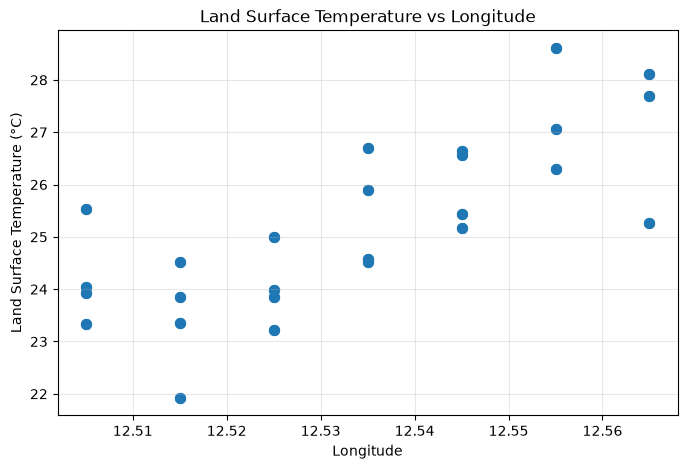

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["lon"],
    df["lst_c"],
    s=50
)

plt.xlabel("Longitude")
plt.ylabel("Land Surface Temperature (°C)")
plt.title("Land Surface Temperature vs Longitude")
plt.grid(True, alpha=0.3)

plt.show()

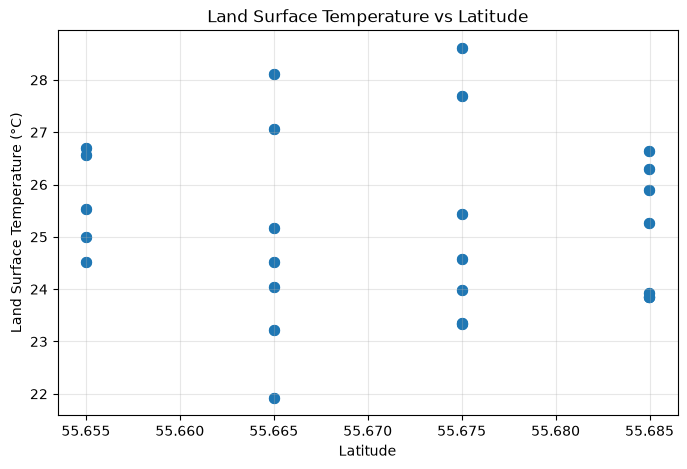

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["lat"],
    df["lst_c"],
    s=50
)

plt.xlabel("Latitude")
plt.ylabel("Land Surface Temperature (°C)")
plt.title("Land Surface Temperature vs Latitude")
plt.grid(True, alpha=0.3)

plt.show()

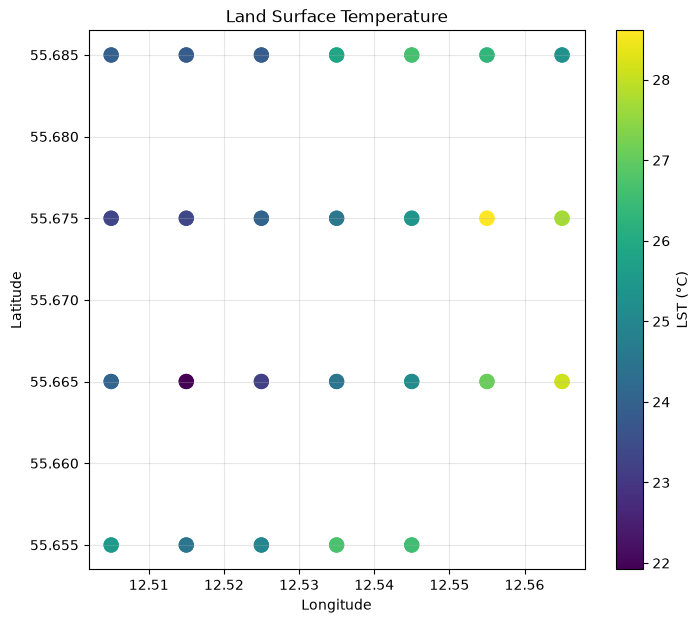

In [9]:
plt.figure(figsize=(8, 7))

scatter = plt.scatter(
    df["lon"],
    df["lat"],
    c=df["lst_c"],
    s=100
)

plt.colorbar(scatter, label="LST (°C)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Land Surface Temperature")

plt.grid(True, alpha=0.3)
plt.show()

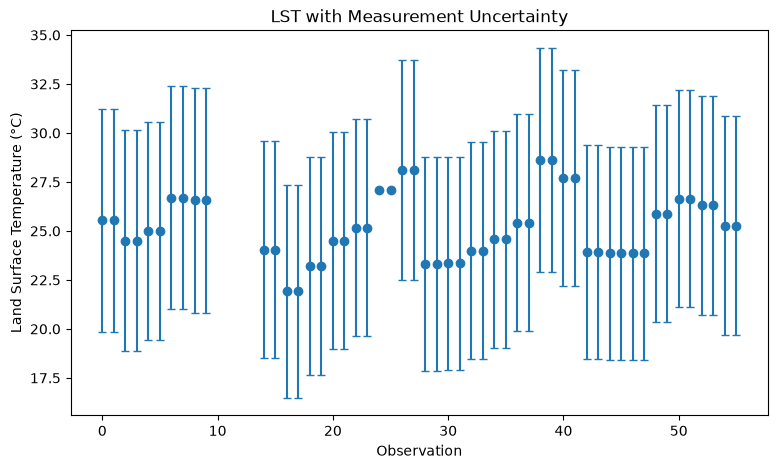

In [10]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    range(len(df)),
    df["lst_c"],
    yerr=df["lst_uncertainty"],
    fmt="o",
    capsize=3
)

plt.xlabel("Observation")
plt.ylabel("Land Surface Temperature (°C)")
plt.title("LST with Measurement Uncertainty")

plt.show()

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Kelvin → Celsius
df["lst_c"] = df["lst"] - 273.15

# Look at the two channels
print(df["channel"].unique())

[10.999001 11.999001]


In [12]:
channel = df["channel"].unique()[0]

plot_df = df[df["channel"] == channel].copy()

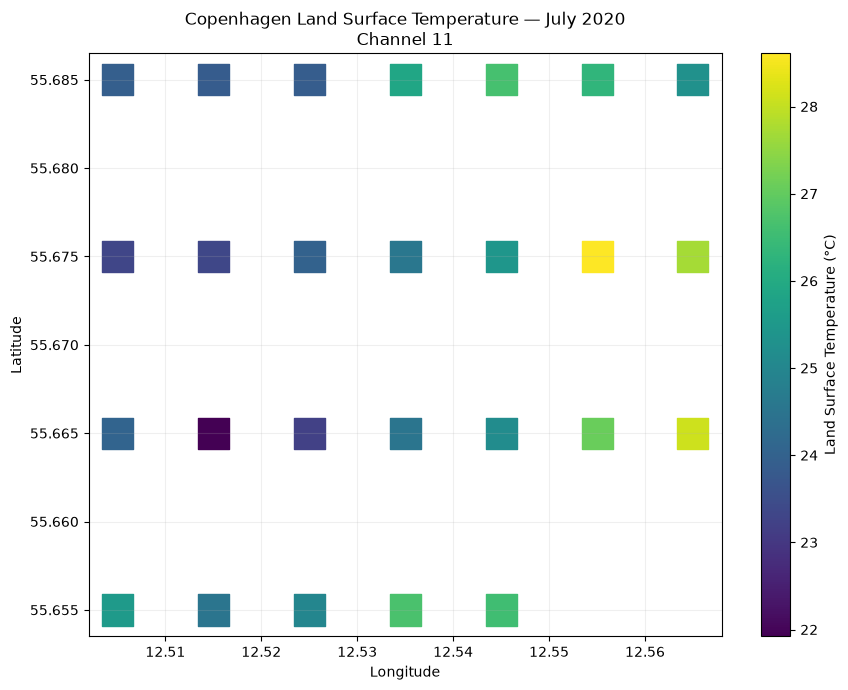

In [13]:
plt.figure(figsize=(9, 7))

heatmap = plt.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df["lst_c"],
    s=500,
    marker="s"
)

plt.colorbar(
    heatmap,
    label="Land Surface Temperature (°C)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"Copenhagen Land Surface Temperature — July 2020\n"
    f"Channel {channel:.0f}"
)

plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

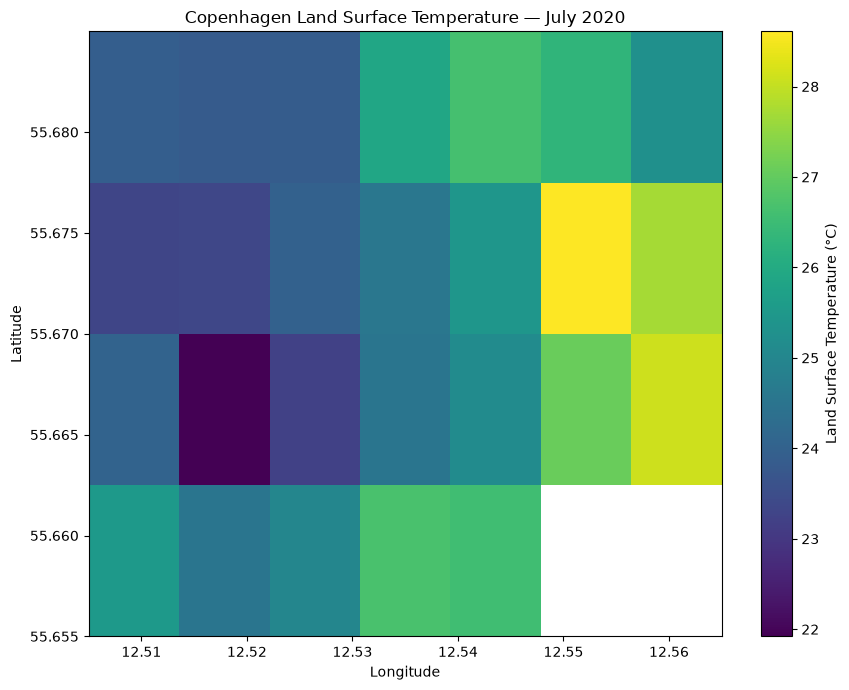

In [14]:
grid = plot_df.pivot(
    index="lat",
    columns="lon",
    values="lst_c"
)

plt.figure(figsize=(9, 7))

plt.imshow(
    grid,
    origin="lower",
    aspect="auto",
    extent=[
        grid.columns.min(),
        grid.columns.max(),
        grid.index.min(),
        grid.index.max()
    ]
)

plt.colorbar(label="Land Surface Temperature (°C)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Copenhagen Land Surface Temperature — July 2020")

plt.tight_layout()
plt.show()

In [15]:
import mysql.connector
from mysql.connector import Error

connection = mysql.connector.connect(
    host=HOST,
    port=PORT,
    user=USERNAME,
    password=PASSWORD,
    database=DATABASE
)

cursor = connection.cursor()
if connection.is_connected():
    print("Connected")

else:
    print("Not connected, check server or credentials")

Connected


In [16]:
cursor.execute("SHOW TABLES;")
tables = [row[0] for row in cursor.fetchall()]
print(f"Found {len(tables)} tables:")
for t in tables:
    print(" -", t)

Found 4 tables:
 - catalogue
 - landcover
 - terrain
 - training_table


In [17]:
table = "training_table"
schema = {}

cursor.execute("""
    SELECT
        COLUMN_NAME,
        DATA_TYPE,
        IS_NULLABLE,
        COLUMN_KEY,
        COLUMN_DEFAULT
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = %s
    ORDER BY ORDINAL_POSITION;
""", (table,))

columns = cursor.fetchall()
schema[table] = columns

print(f"\nTable: {table}")
for col_name, data_type, nullable, key, default in columns:
    key_marker = f" [{key}]" if key else ""
    print(f"  - {col_name} ({data_type}){key_marker}")


Table: training_table
  - id (int) [PRI]
  - longitude (decimal) [MUL]
  - latitude (decimal)
  - elevation_m (decimal)
  - slope_deg (decimal)
  - land_cover_code (tinyint)
  - land_cover_class (varchar)
  - is_built_up (tinyint)


In [18]:
dfs = {}

for table_name, table_info in schema.items():
    query = f"SELECT * FROM {table_name}"
    dfs[table_name] = pd.read_sql(query, connection)

/tmp/ipykernel_363/3869150288.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dfs[table_name] = pd.read_sql(query, connection)


In [19]:
print("LST:")
print(df[["lat", "lon"]].describe())

print("\nLand cover:")
print(dfs["training_table"]["latitude"].describe())
print(dfs["training_table"]["longitude"].describe())

LST:
             lat        lon
count  56.000000  56.000000
mean   55.670002  12.534996
std     0.011280   0.020182
min    55.654995  12.505000
25%    55.662502  12.514995
50%    55.670002  12.534999
75%    55.677498  12.555003
max    55.684994  12.564998

Land cover:
count    576000.000000
mean         55.675000
std           0.014434
min          55.650042
25%          55.662521
50%          55.675000
75%          55.687479
max          55.699958
Name: latitude, dtype: float64
count    576000.000000
mean         12.540000
std           0.023094
min          12.500042
25%          12.520021
50%          12.540000
75%          12.559979
max          12.579958
Name: longitude, dtype: float64


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Get the land-cover data
# -------------------------------------------------------

land_cover = dfs["training_table"].copy()

# Make sure coordinates and built-up indicator are numeric
df["lat"] = pd.to_numeric(df["lat"])
df["lon"] = pd.to_numeric(df["lon"])

land_cover["latitude"] = pd.to_numeric(land_cover["latitude"])
land_cover["longitude"] = pd.to_numeric(land_cover["longitude"])
land_cover["is_built_up"] = pd.to_numeric(land_cover["is_built_up"])


# -------------------------------------------------------
# 2. Keep one LST channel
# -------------------------------------------------------

print("Available channels:", df["channel"].unique())

channel = df["channel"].unique()[0]

lst = df[df["channel"] == channel].copy()

print("LST observations:", len(lst))


# -------------------------------------------------------
# 3. Determine the LST grid
# -------------------------------------------------------

lats = np.sort(lst["lat"].unique())
lons = np.sort(lst["lon"].unique())

lat_resolution = np.median(np.diff(lats))
lon_resolution = np.median(np.diff(lons))

print("LST latitude resolution:", lat_resolution)
print("LST longitude resolution:", lon_resolution)


# -------------------------------------------------------
# 4. Create LST pixel boundaries
# -------------------------------------------------------

lat_edges = np.concatenate([
    [lats[0] - lat_resolution / 2],
    (lats[:-1] + lats[1:]) / 2,
    [lats[-1] + lat_resolution / 2]
])

lon_edges = np.concatenate([
    [lons[0] - lon_resolution / 2],
    (lons[:-1] + lons[1:]) / 2,
    [lons[-1] + lon_resolution / 2]
])


# -------------------------------------------------------
# 5. Assign each land-cover pixel to an LST pixel
# -------------------------------------------------------

land_cover["lst_lat"] = pd.cut(
    land_cover["latitude"],
    bins=lat_edges,
    labels=lats,
    include_lowest=True
)

land_cover["lst_lon"] = pd.cut(
    land_cover["longitude"],
    bins=lon_edges,
    labels=lons,
    include_lowest=True
)

land_cover["lst_lat"] = land_cover["lst_lat"].astype(float)
land_cover["lst_lon"] = land_cover["lst_lon"].astype(float)


# -------------------------------------------------------
# 6. Calculate built-up percentage per LST pixel
# -------------------------------------------------------

built_up = (
    land_cover
    .dropna(subset=["lst_lat", "lst_lon"])
    .groupby(["lst_lat", "lst_lon"])
    .agg(
        built_fraction=("is_built_up", "mean"),
        n_landcover_pixels=("is_built_up", "count")
    )
    .reset_index()
)

built_up["built_percent"] = built_up["built_fraction"] * 100


# -------------------------------------------------------
# 7. Merge built-up percentage with LST
# -------------------------------------------------------

lst_analysis = lst.merge(
    built_up[
        ["lst_lat", "lst_lon", "built_percent", "n_landcover_pixels"]
    ],
    left_on=["lat", "lon"],
    right_on=["lst_lat", "lst_lon"],
    how="left"
)

# Kelvin → Celsius
lst_analysis["lst_c"] = lst_analysis["lst"] - 273.15


# -------------------------------------------------------
# 8. Inspect the result
# -------------------------------------------------------

print(
    lst_analysis[
        [
            "lat",
            "lon",
            "lst_c",
            "built_percent",
            "n_landcover_pixels"
        ]
    ]
)

Available channels: [10.999001 11.999001]
LST observations: 28
LST latitude resolution: 0.009994507
LST longitude resolution: 0.009994507
          lat        lon      lst_c  built_percent  n_landcover_pixels
0   55.654995  12.505000  25.540009      83.645833               14400
1   55.654995  12.514995  24.510010      88.347222               14400
2   55.654995  12.524989  24.989990      50.645833               14400
3   55.654995  12.534999  26.700012      58.923611               14400
4   55.654995  12.544993  26.570007      82.243056               14400
5   55.654995  12.555003        NaN      77.798611               14400
6   55.654995  12.564998        NaN      43.875000               14400
7   55.665005  12.505000  24.049988      70.680556               14400
8   55.665005  12.514995  21.920013      83.645833               14400
9   55.665005  12.524989  23.220001      32.263889               14400
10  55.665005  12.534999  24.510010      70.965278               14400
11  55.665

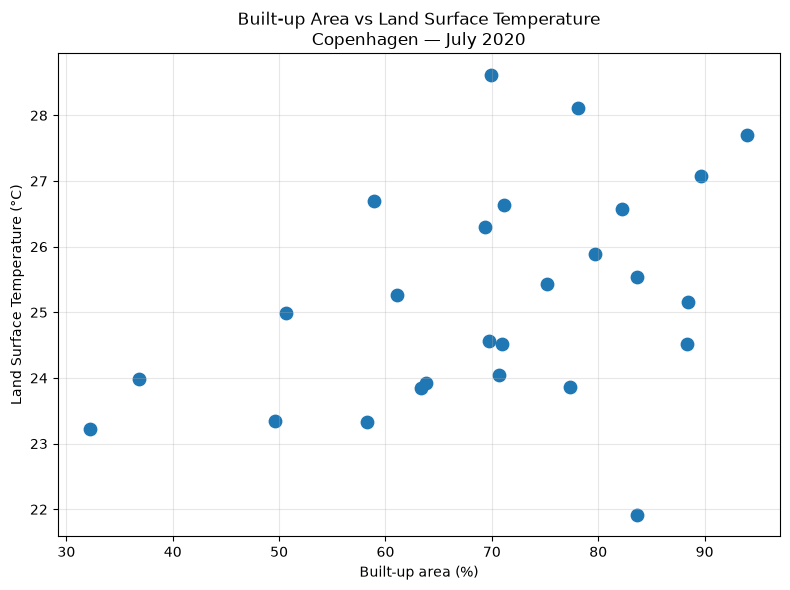

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    lst_analysis["built_percent"],
    lst_analysis["lst_c"],
    s=80
)

plt.xlabel("Built-up area (%)")
plt.ylabel("Land Surface Temperature (°C)")
plt.title(
    "Built-up Area vs Land Surface Temperature\n"
    "Copenhagen — July 2020"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

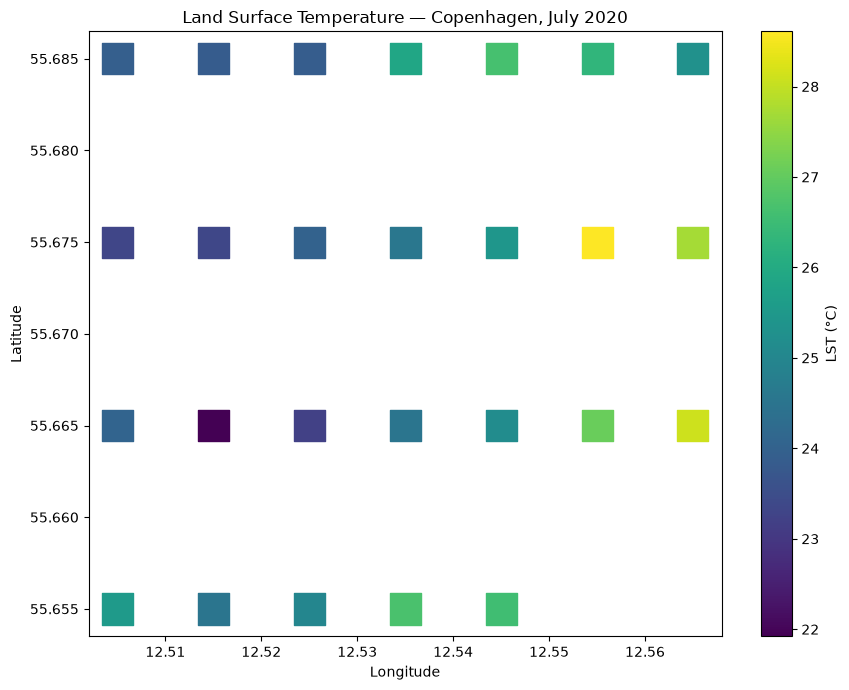

In [22]:
plt.figure(figsize=(9, 7))

sc = plt.scatter(
    lst_analysis["lon"],
    lst_analysis["lat"],
    c=lst_analysis["lst_c"],
    s=500,
    marker="s"
)

plt.colorbar(sc, label="LST (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Land Surface Temperature — Copenhagen, July 2020")

plt.tight_layout()
plt.show()

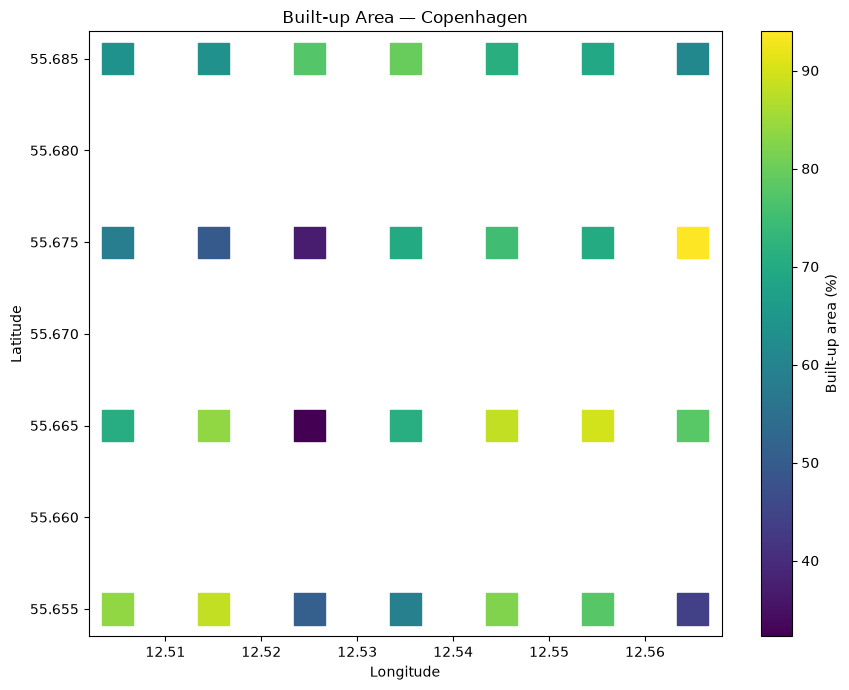

In [23]:
plt.figure(figsize=(9, 7))

sc = plt.scatter(
    lst_analysis["lon"],
    lst_analysis["lat"],
    c=lst_analysis["built_percent"],
    s=500,
    marker="s"
)

plt.colorbar(sc, label="Built-up area (%)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Built-up Area — Copenhagen")

plt.tight_layout()
plt.show()

In [24]:
import folium
import branca.colormap as cm
import numpy as np

# ---------------------------------------------------------
# 1. Make sure we are working with one LST channel
# ---------------------------------------------------------

print("Available channels:", df["channel"].unique())

channel = df["channel"].unique()[0]

lst = df[df["channel"] == channel].copy()

# Convert Kelvin -> Celsius
lst["lst_c"] = lst["lst"] - 273.15


# ---------------------------------------------------------
# 2. Calculate built-up percentage inside each LST pixel
# ---------------------------------------------------------

land_cover = dfs["training_table"].copy()

# Make sure coordinates and built-up indicator are numeric
land_cover["latitude"] = pd.to_numeric(
    land_cover["latitude"], errors="coerce"
)

land_cover["longitude"] = pd.to_numeric(
    land_cover["longitude"], errors="coerce"
)

land_cover["is_built_up"] = pd.to_numeric(
    land_cover["is_built_up"], errors="coerce"
)


# LST grid coordinates
lats = np.sort(lst["lat"].unique())
lons = np.sort(lst["lon"].unique())

lat_resolution = np.median(np.diff(lats))
lon_resolution = np.median(np.diff(lons))

print("LST latitude resolution:", lat_resolution)
print("LST longitude resolution:", lon_resolution)


# Boundaries of the LST pixels
lat_edges = np.concatenate([
    [lats[0] - lat_resolution / 2],
    (lats[:-1] + lats[1:]) / 2,
    [lats[-1] + lat_resolution / 2]
])

lon_edges = np.concatenate([
    [lons[0] - lon_resolution / 2],
    (lons[:-1] + lons[1:]) / 2,
    [lons[-1] + lon_resolution / 2]
])


# Assign every land-cover pixel to an LST pixel
land_cover["lst_lat"] = pd.cut(
    land_cover["latitude"],
    bins=lat_edges,
    labels=lats,
    include_lowest=True
)

land_cover["lst_lon"] = pd.cut(
    land_cover["longitude"],
    bins=lon_edges,
    labels=lons,
    include_lowest=True
)

land_cover["lst_lat"] = land_cover["lst_lat"].astype(float)
land_cover["lst_lon"] = land_cover["lst_lon"].astype(float)


# Calculate percentage built-up per LST pixel
built_up = (
    land_cover
    .dropna(subset=["lst_lat", "lst_lon"])
    .groupby(["lst_lat", "lst_lon"])
    .agg(
        built_fraction=("is_built_up", "mean"),
        n_landcover_pixels=("is_built_up", "count")
    )
    .reset_index()
)

built_up["built_percent"] = built_up["built_fraction"] * 100


# ---------------------------------------------------------
# 3. Combine LST and built-up information
# ---------------------------------------------------------

lst_analysis = lst.merge(
    built_up[
        [
            "lst_lat",
            "lst_lon",
            "built_percent",
            "n_landcover_pixels"
        ]
    ],
    left_on=["lat", "lon"],
    right_on=["lst_lat", "lst_lon"],
    how="left"
)

print(lst_analysis[
    ["lat", "lon", "lst_c", "built_percent"]
].head())

Available channels: [10.999001 11.999001]
LST latitude resolution: 0.009994507
LST longitude resolution: 0.009994507
         lat        lon      lst_c  built_percent
0  55.654995  12.505000  25.540009      83.645833
1  55.654995  12.514995  24.510010      88.347222
2  55.654995  12.524989  24.989990      50.645833
3  55.654995  12.534999  26.700012      58.923611
4  55.654995  12.544993  26.570007      82.243056


In [25]:
import folium
import branca.colormap as cm
import numpy as np

# ---------------------------------------------------------
# Create map centered on Copenhagen
# ---------------------------------------------------------

center_lat = lst_analysis["lat"].mean()
center_lon = lst_analysis["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="OpenStreetMap"
)


# ---------------------------------------------------------
# Temperature colour scale
# ---------------------------------------------------------

min_temp = lst_analysis["lst_c"].min()
max_temp = lst_analysis["lst_c"].max()

temp_colormap = cm.LinearColormap(
    colors=["blue", "cyan", "yellow", "orange", "red"],
    vmin=min_temp,
    vmax=max_temp
)

temp_colormap.caption = "Land Surface Temperature (°C)"
temp_colormap.add_to(m)


# ---------------------------------------------------------
# Draw each LST pixel
# ---------------------------------------------------------

for _, row in lst_analysis.dropna(subset=["lst_c"]).iterrows():

    lat = row["lat"]
    lon = row["lon"]

    # Half the LST pixel size
    half_lat = lat_resolution / 2
    half_lon = lon_resolution / 2

    bounds = [
        [lat - half_lat, lon - half_lon],
        [lat + half_lat, lon + half_lon]
    ]

    color = temp_colormap(row["lst_c"])

    popup_text = f"""
    <b>LST pixel</b><br>
    Latitude: {lat:.5f}<br>
    Longitude: {lon:.5f}<br>
    LST: {row["lst_c"]:.2f} °C<br>
    Built-up: {row["built_percent"]:.1f} %
    """

    folium.Rectangle(
        bounds=bounds,
        color=None,
        fill=True,
        fill_color=color,
        fill_opacity=0.65,
        popup=folium.Popup(
            popup_text,
            max_width=250
        )
    ).add_to(m)


# ---------------------------------------------------------
# Save map
# ---------------------------------------------------------

m.save("copenhagen_lst_map.html")

m

In [26]:
# ---------------------------------------------------------
# Built-up percentage map
# ---------------------------------------------------------

m_built = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="OpenStreetMap"
)


# Built-up colour scale
built_colormap = cm.LinearColormap(
    colors=["white", "yellow", "orange", "red"],
    vmin=0,
    vmax=100
)

built_colormap.caption = "Built-up area (%)"
built_colormap.add_to(m_built)


for _, row in lst_analysis.dropna(
    subset=["built_percent"]
).iterrows():

    lat = row["lat"]
    lon = row["lon"]

    half_lat = lat_resolution / 2
    half_lon = lon_resolution / 2

    bounds = [
        [lat - half_lat, lon - half_lon],
        [lat + half_lat, lon + half_lon]
    ]

    color = built_colormap(row["built_percent"])

    popup_text = f"""
    <b>Land-cover pixel aggregation</b><br>
    Latitude: {lat:.5f}<br>
    Longitude: {lon:.5f}<br>
    Built-up: {row["built_percent"]:.1f}%<br>
    LST: {row["lst_c"]:.2f} °C
    """

    folium.Rectangle(
        bounds=bounds,
        color=None,
        fill=True,
        fill_color=color,
        fill_opacity=0.65,
        popup=folium.Popup(
            popup_text,
            max_width=250
        )
    ).add_to(m_built)


m_built.save("copenhagen_built_up_map.html")

m_built

In [27]:
m_combined = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="OpenStreetMap"
)


# -----------------------------
# LST layer
# -----------------------------

lst_layer = folium.FeatureGroup(
    name="🌡️ Land Surface Temperature"
)

for _, row in lst_analysis.dropna(subset=["lst_c"]).iterrows():

    lat = row["lat"]
    lon = row["lon"]

    bounds = [
        [lat - lat_resolution / 2,
         lon - lon_resolution / 2],

        [lat + lat_resolution / 2,
         lon + lon_resolution / 2]
    ]

    color = temp_colormap(row["lst_c"])

    popup = f"""
    <b>Land Surface Temperature</b><br><br>
    LST: <b>{row["lst_c"]:.2f} °C</b><br>
    Built-up: {row["built_percent"]:.1f}%<br>
    Latitude: {lat:.5f}<br>
    Longitude: {lon:.5f}
    """

    folium.Rectangle(
        bounds=bounds,
        fill=True,
        fill_color=color,
        fill_opacity=0.65,
        color=None,
        popup=folium.Popup(popup, max_width=250)
    ).add_to(lst_layer)

lst_layer.add_to(m_combined)


# -----------------------------
# Built-up layer
# -----------------------------

built_layer = folium.FeatureGroup(
    name="🏙️ Built-up percentage",
    show=False
)

for _, row in lst_analysis.dropna(
    subset=["built_percent"]
).iterrows():

    lat = row["lat"]
    lon = row["lon"]

    bounds = [
        [lat - lat_resolution / 2,
         lon - lon_resolution / 2],

        [lat + lat_resolution / 2,
         lon + lon_resolution / 2]
    ]

    color = built_colormap(row["built_percent"])

    popup = f"""
    <b>Built-up area</b><br><br>
    Built-up: <b>{row["built_percent"]:.1f}%</b><br>
    LST: {row["lst_c"]:.2f} °C
    """

    folium.Rectangle(
        bounds=bounds,
        fill=True,
        fill_color=color,
        fill_opacity=0.65,
        color=None,
        popup=folium.Popup(popup, max_width=250)
    ).add_to(built_layer)

built_layer.add_to(m_combined)


# Layer selector
folium.LayerControl().add_to(m_combined)


m_combined.save("copenhagen_lst_built_combined.html")

m_combined
